# Algoritmos Genéticos — Asesor de Inversiones
**Lizbeth Hernández**

Este notebook implementa dos versiones del algoritmo genético para el problema del asesor de inversiones:
1. **Implementación desde cero** (basada en Benítez Iglésias, 2014)
2. **Implementación con la librería DEAP**

---
## Descripción del Problema

Una empresa ofrece a sus clientes la posibilidad de invertir en bonos de 5 compañías (A, B, C, D, E). Cada bono tiene **precio**, **cantidad disponible** y **rendimiento**. El objetivo es maximizar el rendimiento total sin exceder el capital disponible del cliente.

## Datos del Problema

| Bono | Precio | Cantidad | Rendimiento |
|------|--------|----------|-------------|
| A    | 500    | 5        | 0.15        |
| B    | 700    | 6        | 0.05        |
| C    | 300    | 10       | 0.03        |
| D    | 800    | 3        | 0.10        |
| E    | 400    | 7        | 0.10        |

**Capital disponible del cliente:** $10,000

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── Datos del problema ───────────────────────────────────────────────────────
BONOS       = ['A', 'B', 'C', 'D', 'E']
PRECIOS     = [500, 700, 300, 800, 400]   # Precio por bono
CANTIDADES  = [5,   6,  10,   3,   7]    # Unidades disponibles
RENDIMIENTOS= [0.15, 0.05, 0.03, 0.10, 0.10]  # Rendimiento por bono
CAPITAL     = 10_000                      # Capital del cliente

N_BONOS = len(BONOS)
print('Datos del problema cargados correctamente.')
print(f'Capital disponible: ${CAPITAL:,}')

Datos del problema cargados correctamente.
Capital disponible: $10,000


---
# PARTE 1: Algoritmo Genético desde cero
*(Basado en Benítez Iglésias, R. (2014). Inteligencia artificial avanzada. Editorial UOC.)*

### Codificación del Cromosoma
Cada individuo es un vector de enteros `[nA, nB, nC, nD, nE]` donde `n_i ∈ [0, cantidad_i]` indica cuántos bonos del tipo `i` se compran.

In [2]:
# ─── Función objetivo: rendimiento total ──────────────────────────────────────
def funcion_objetivo(individuo):
    """Calcula el rendimiento total de una combinación de bonos.
    Rendimiento_i = n_i * precio_i * rendimiento_i
    """
    return sum(
        individuo[i] * PRECIOS[i] * RENDIMIENTOS[i]
        for i in range(N_BONOS)
    )

def costo_total(individuo):
    """Calcula el costo total de inversión."""
    return sum(individuo[i] * PRECIOS[i] for i in range(N_BONOS))

# ─── Fitness con penalización por restricción de capital ─────────────────────
def fitness(individuo):
    """Si el costo supera el capital, se penaliza fuertemente el individuo."""
    costo = costo_total(individuo)
    if costo > CAPITAL:
        return 0.0  # Individuo inválido: penalización total
    return funcion_objetivo(individuo)

# ─── Generación de la población inicial ──────────────────────────────────────
def crear_individuo():
    """Genera un individuo válido (respeta límites de cantidad)."""
    return [random.randint(0, CANTIDADES[i]) for i in range(N_BONOS)]

def crear_poblacion(tam_poblacion):
    return [crear_individuo() for _ in range(tam_poblacion)]

print('Funciones de la Parte 1 definidas.')

Funciones de la Parte 1 definidas.


In [3]:
# ─── Selección: Ruleta (Roulette Wheel / Fitness Proportionate) ───────────────
def seleccion_ruleta(poblacion, fitnesses):
    """Selecciona un individuo con probabilidad proporcional a su fitness."""
    total_fit = sum(fitnesses)
    if total_fit == 0:  # Toda la población es inválida
        return random.choice(poblacion)
    pick = random.uniform(0, total_fit)
    acumulado = 0
    for individuo, fit in zip(poblacion, fitnesses):
        acumulado += fit
        if acumulado >= pick:
            return individuo
    return poblacion[-1]

# ─── Cruzamiento: Un punto ────────────────────────────────────────────────────
def cruzamiento_un_punto(padre1, padre2):
    """Cruza dos padres en un punto aleatorio para generar dos hijos."""
    punto = random.randint(1, N_BONOS - 1)
    hijo1 = padre1[:punto] + padre2[punto:]
    hijo2 = padre2[:punto] + padre1[punto:]
    return hijo1, hijo2

# ─── Mutación: Cambio aleatorio de un gen ─────────────────────────────────────
def mutacion(individuo, prob_mutacion=0.1):
    """Con probabilidad prob_mutacion, cambia aleatoriamente un gen."""
    individuo = individuo[:]
    for i in range(N_BONOS):
        if random.random() < prob_mutacion:
            individuo[i] = random.randint(0, CANTIDADES[i])
    return individuo

print('Operadores genéticos definidos.')

Operadores genéticos definidos.


In [4]:
# ─── Algoritmo Genético Principal (desde cero) ───────────────────────────────
def algoritmo_genetico(
    tam_poblacion=100,
    n_generaciones=200,
    prob_cruzamiento=0.8,
    prob_mutacion=0.05,
    seed=42
):
    random.seed(seed)
    
    poblacion = crear_poblacion(tam_poblacion)
    historial_mejor = []
    historial_promedio = []
    mejor_global = None
    mejor_fitness_global = -1

    for gen in range(n_generaciones):
        fitnesses = [fitness(ind) for ind in poblacion]
        
        # Rastrear el mejor de esta generación
        mejor_idx = fitnesses.index(max(fitnesses))
        if fitnesses[mejor_idx] > mejor_fitness_global:
            mejor_fitness_global = fitnesses[mejor_idx]
            mejor_global = poblacion[mejor_idx][:]
        
        historial_mejor.append(mejor_fitness_global)
        historial_promedio.append(np.mean(fitnesses))
        
        # Crear nueva generación mediante selección + cruzamiento + mutación
        nueva_poblacion = [mejor_global[:]]  # Elitismo: conservar el mejor
        
        while len(nueva_poblacion) < tam_poblacion:
            padre1 = seleccion_ruleta(poblacion, fitnesses)
            padre2 = seleccion_ruleta(poblacion, fitnesses)
            
            if random.random() < prob_cruzamiento:
                hijo1, hijo2 = cruzamiento_un_punto(padre1, padre2)
            else:
                hijo1, hijo2 = padre1[:], padre2[:]
            
            hijo1 = mutacion(hijo1, prob_mutacion)
            hijo2 = mutacion(hijo2, prob_mutacion)
            nueva_poblacion.extend([hijo1, hijo2])
        
        poblacion = nueva_poblacion[:tam_poblacion]

    return mejor_global, mejor_fitness_global, historial_mejor, historial_promedio

# ─── Ejecutar ─────────────────────────────────────────────────────────────────
print('Ejecutando Algoritmo Genético desde cero...')
mejor_ind, mejor_fit, hist_mejor, hist_promedio = algoritmo_genetico()

print('\n=== RESULTADO (AG desde cero) ===')
print(f'Combinación óptima: {dict(zip(BONOS, mejor_ind))}')
print(f'Costo total: ${costo_total(mejor_ind):,.0f}')
print(f'Capital disponible: ${CAPITAL:,}')
print(f'Capital no utilizado: ${CAPITAL - costo_total(mejor_ind):,.0f}')
print(f'Rendimiento máximo obtenido: ${mejor_fit:,.2f}')

Ejecutando Algoritmo Genético desde cero...

=== RESULTADO (AG desde cero) ===
Combinación óptima: {'A': 5, 'B': 3, 'C': 0, 'D': 3, 'E': 7}
Costo total: $9,800
Capital disponible: $10,000
Capital no utilizado: $200
Rendimiento máximo obtenido: $1,000.00


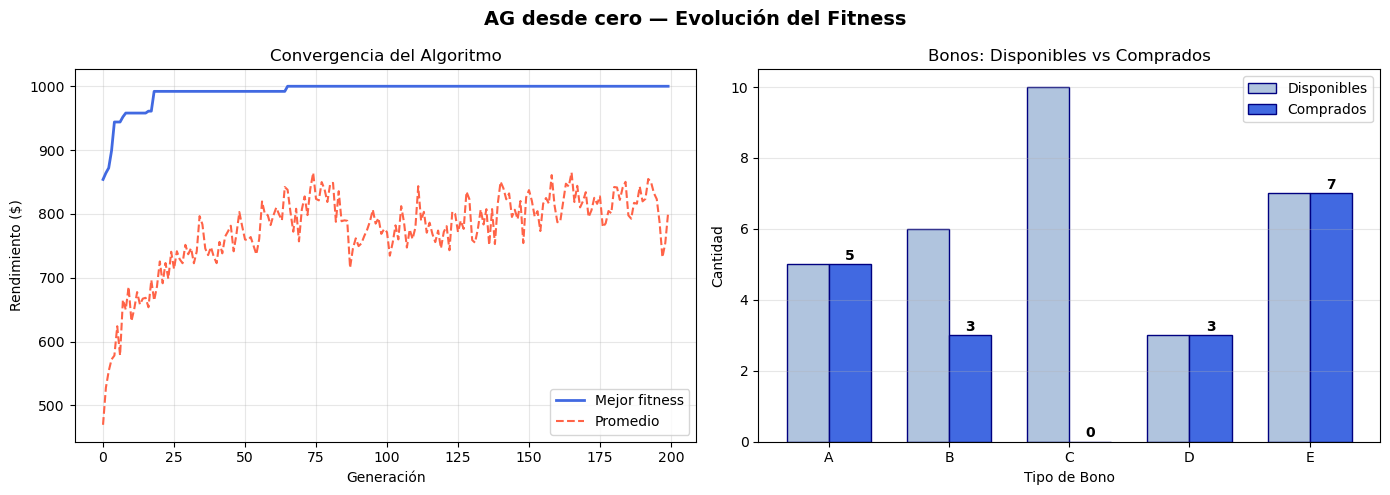

In [6]:
# ─── Gráfica 1: Evolución del fitness (AG desde cero) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AG desde cero — Evolución del Fitness', fontsize=14, fontweight='bold')

axes[0].plot(hist_mejor, color='royalblue', linewidth=2, label='Mejor fitness')
axes[0].plot(hist_promedio, color='tomato', linewidth=1.5, linestyle='--', label='Promedio')
axes[0].set_title('Convergencia del Algoritmo')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('Rendimiento ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica de barras: bonos comprados vs disponibles
x = np.arange(N_BONOS)
ancho = 0.35
bars1 = axes[1].bar(x - ancho/2, CANTIDADES, ancho, label='Disponibles', color='lightsteelblue', edgecolor='navy')
bars2 = axes[1].bar(x + ancho/2, mejor_ind, ancho, label='Comprados', color='royalblue', edgecolor='navy')
axes[1].set_title('Bonos: Disponibles vs Comprados')
axes[1].set_xlabel('Tipo de Bono')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(x)
axes[1].set_xticklabels(BONOS)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Etiquetas en las barras
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.05, f'{int(h)}',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('grafica_ag_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE 2: Algoritmo Genético con la librería DEAP

DEAP (Distributed Evolutionary Algorithms in Python) es un framework especializado para computación evolutiva que proporciona operadores genéticos optimizados y estructuras de datos avanzadas.

In [7]:
from deap import base, creator, tools, algorithms

# ─── Configuración de DEAP ────────────────────────────────────────────────────
# Evitar redefinición si la celda se ejecuta más de una vez
if hasattr(creator, 'FitnessMax'):
    del creator.FitnessMax
if hasattr(creator, 'Individual'):
    del creator.Individual

# Maximizar el fitness (weights=(1.0,) = maximización)
creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# ─── Función objetivo DEAP ────────────────────────────────────────────────────
def evaluar_inversion(individuo):
    """Función de evaluación para DEAP. Retorna una tupla (fitness,).
    DEAP requiere siempre retornar una tupla, incluso para un solo objetivo.
    """
    costo = sum(individuo[i] * PRECIOS[i] for i in range(N_BONOS))
    if costo > CAPITAL:
        return (0.0,)  # Penalización
    rendimiento = sum(individuo[i] * PRECIOS[i] * RENDIMIENTOS[i] for i in range(N_BONOS))
    return (rendimiento,)

# ─── Generador de atributos por gen (respeta límites de cantidad) ─────────────
def gen_aleatorio(idx):
    return random.randint(0, CANTIDADES[idx])

# Registrar generador de individuos
toolbox.register('individual', tools.initCycle, creator.Individual,
                 [lambda i=i: gen_aleatorio(i) for i in range(N_BONOS)], n=1)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)

# ─── Operadores genéticos DEAP ────────────────────────────────────────────────
toolbox.register('evaluate', evaluar_inversion)

# Selección: Torneo (más robusto que ruleta para poblaciones pequeñas)
toolbox.register('select', tools.selTournament, tournsize=3)

# Cruzamiento: Un punto
toolbox.register('mate', tools.cxOnePoint)

# Mutación: Uniforme por entero, respetando límites
toolbox.register('mutate', tools.mutUniformInt,
                 low=0, up=CANTIDADES, indpb=0.2)

print('DEAP configurado correctamente.')

DEAP configurado correctamente.


In [8]:
# ─── Ejecutar AG con DEAP ─────────────────────────────────────────────────────
random.seed(42)

TAM_POB = 100
N_GEN   = 200
CXPB    = 0.8   # Probabilidad de cruzamiento
MUTPB   = 0.05  # Probabilidad de mutación por individuo

poblacion_deap = toolbox.population(n=TAM_POB)

# Estadísticas a registrar
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('max',  np.max)
stats.register('mean', np.mean)
stats.register('min',  np.min)

# Hall of fame: conserva el mejor individuo histórico
hof = tools.HallOfFame(1)

print('Ejecutando Algoritmo Genético con DEAP...')
poblacion_final, logbook = algorithms.eaSimple(
    poblacion_deap, toolbox,
    cxpb=CXPB, mutpb=MUTPB,
    ngen=N_GEN,
    stats=stats, halloffame=hof,
    verbose=False
)

mejor_deap = list(hof[0])
mejor_fit_deap = hof[0].fitness.values[0]

print('\n=== RESULTADO (DEAP) ===')
print(f'Combinación óptima: {dict(zip(BONOS, mejor_deap))}')
print(f'Costo total: ${sum(mejor_deap[i]*PRECIOS[i] for i in range(N_BONOS)):,.0f}')
print(f'Capital disponible: ${CAPITAL:,}')
print(f'Capital no utilizado: ${CAPITAL - sum(mejor_deap[i]*PRECIOS[i] for i in range(N_BONOS)):,.0f}')
print(f'Rendimiento máximo obtenido: ${mejor_fit_deap:,.2f}')

Ejecutando Algoritmo Genético con DEAP...

=== RESULTADO (DEAP) ===
Combinación óptima: {'A': 5, 'B': 2, 'C': 3, 'D': 3, 'E': 7}
Costo total: $10,000
Capital disponible: $10,000
Capital no utilizado: $0
Rendimiento máximo obtenido: $992.00


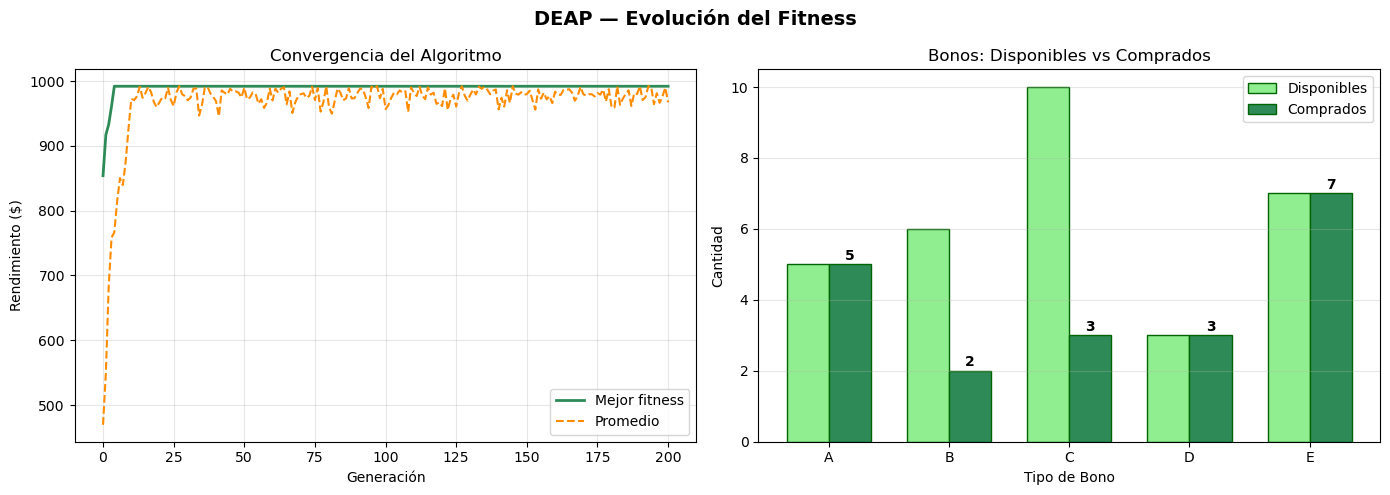

In [9]:
# ─── Gráfica 2: Evolución del fitness (DEAP) ──────────────────────────────────
gen_log  = logbook.select('gen')
max_log  = logbook.select('max')
mean_log = logbook.select('mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DEAP — Evolución del Fitness', fontsize=14, fontweight='bold')

axes[0].plot(gen_log, max_log,  color='seagreen', linewidth=2, label='Mejor fitness')
axes[0].plot(gen_log, mean_log, color='darkorange', linewidth=1.5, linestyle='--', label='Promedio')
axes[0].set_title('Convergencia del Algoritmo')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('Rendimiento ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

x = np.arange(N_BONOS)
ancho = 0.35
bars1 = axes[1].bar(x - ancho/2, CANTIDADES, ancho, label='Disponibles', color='lightgreen', edgecolor='darkgreen')
bars2 = axes[1].bar(x + ancho/2, mejor_deap,  ancho, label='Comprados',  color='seagreen',  edgecolor='darkgreen')
axes[1].set_title('Bonos: Disponibles vs Comprados')
axes[1].set_xlabel('Tipo de Bono')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(x)
axes[1].set_xticklabels(BONOS)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.05, f'{int(h)}',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('grafica_deap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE 3: Comparación de Soluciones

In [10]:
# ─── Tabla comparativa de resultados ─────────────────────────────────────────
print('=' * 60)
print(f'{"COMPARACIÓN DE RESULTADOS":^60}')
print('=' * 60)
print(f'{"Criterio":<30} {"AG Scratch":>13} {"DEAP":>13}')
print('-' * 60)

costo_scratch = costo_total(mejor_ind)
costo_deap    = sum(mejor_deap[i] * PRECIOS[i] for i in range(N_BONOS))

for i, bono in enumerate(BONOS):
    print(f'  Bonos {bono} comprados{"":<17} {mejor_ind[i]:>13} {mejor_deap[i]:>13}')
print('-' * 60)
print(f'{"Costo total ($)":<30} {costo_scratch:>13,.0f} {costo_deap:>13,.0f}')
print(f'{"Capital restante ($)":<30} {CAPITAL-costo_scratch:>13,.0f} {CAPITAL-costo_deap:>13,.0f}')
print(f'{"Rendimiento obtenido ($)":<30} {mejor_fit:>13,.2f} {mejor_fit_deap:>13,.2f}')
print('=' * 60)

                 COMPARACIÓN DE RESULTADOS                  
Criterio                          AG Scratch          DEAP
------------------------------------------------------------
  Bonos A comprados                              5             5
  Bonos B comprados                              3             2
  Bonos C comprados                              0             3
  Bonos D comprados                              3             3
  Bonos E comprados                              7             7
------------------------------------------------------------
Costo total ($)                        9,800        10,000
Capital restante ($)                     200             0
Rendimiento obtenido ($)            1,000.00        992.00


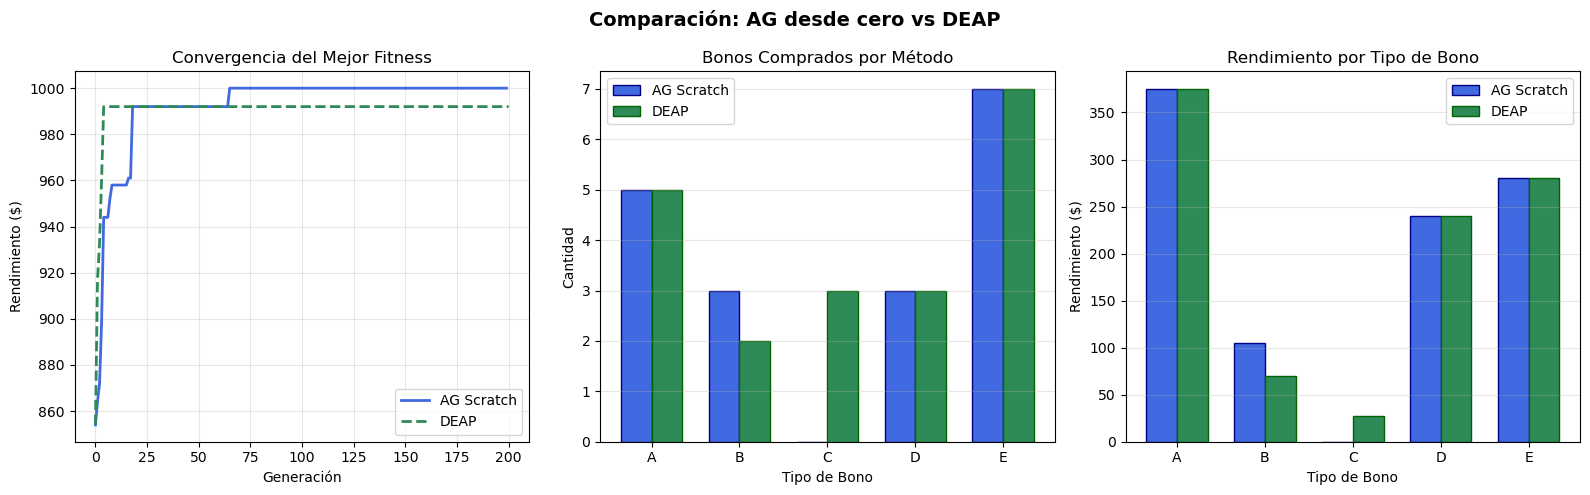

In [12]:
# ─── Gráfica comparativa final ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación: AG desde cero vs DEAP', fontsize=14, fontweight='bold')

# 1) Convergencia superpuesta
axes[0].plot(hist_mejor, color='royalblue', linewidth=2, label='AG Scratch')
axes[0].plot(gen_log, max_log, color='seagreen', linewidth=2, linestyle='--', label='DEAP')
axes[0].set_title('Convergencia del Mejor Fitness')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('Rendimiento ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) Barras: bonos comprados por cada método
x = np.arange(N_BONOS)
ancho = 0.35
axes[1].bar(x - ancho/2, mejor_ind,  ancho, label='AG Scratch', color='royalblue',  edgecolor='navy')
axes[1].bar(x + ancho/2, mejor_deap, ancho, label='DEAP',       color='seagreen',   edgecolor='darkgreen')
axes[1].set_title('Bonos Comprados por Método')
axes[1].set_xlabel('Tipo de Bono')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(x)
axes[1].set_xticklabels(BONOS)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# 3) Rendimiento por tipo de bono para cada método
rend_scratch = [mejor_ind[i] * PRECIOS[i] * RENDIMIENTOS[i] for i in range(N_BONOS)]
rend_deap    = [mejor_deap[i] * PRECIOS[i] * RENDIMIENTOS[i] for i in range(N_BONOS)]
axes[2].bar(x - ancho/2, rend_scratch, ancho, label='AG Scratch', color='royalblue', edgecolor='navy')
axes[2].bar(x + ancho/2, rend_deap,   ancho, label='DEAP',       color='seagreen',  edgecolor='darkgreen')
axes[2].set_title('Rendimiento por Tipo de Bono')
axes[2].set_xlabel('Tipo de Bono')
axes[2].set_ylabel('Rendimiento ($)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(BONOS)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('grafica_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE 4: Diferencias entre las implementaciones

## 4.1 Función Objetivo

| Aspecto | AG desde cero | DEAP |
|---|---|---|
| Retorno | `float` directo | **Tupla** `(float,)` obligatoria |
| Penalización | `return 0.0` si excede capital | `return (0.0,)` si excede capital |
| Registro | Función Python estándar | Se registra en el `toolbox` con `toolbox.register('evaluate', ...)` |

## 4.2 Fitness

| Aspecto | AG desde cero | DEAP |
|---|---|---|
| Estructura | Lista de floats calculados manualmente | Objeto `creator.FitnessMax` con `weights=(1.0,)` |
| Maximización | Implícita (se toma el max de la lista) | Explícita con `weights=(1.0,)` en `creator.create` |
| Almacenamiento | Variable externa | Atributo `.fitness.values` del individuo |

## 4.3 Operadores de Selección, Cruzamiento y Mutación

| Operador | AG desde cero | DEAP |
|---|---|---|
| **Selección** | Ruleta (`seleccion_ruleta`) — proporcional al fitness | **Torneo** (`tools.selTournament`, k=3) — más robusto ante fitness cero |
| **Cruzamiento** | Un punto codificado manualmente | `tools.cxOnePoint` — implementación optimizada |
| **Mutación** | Cambio aleatorio por gen con prob. uniforme | `tools.mutUniformInt` — respeta límites `[low, up]` por gen |
| **Elitismo** | Manual: se copia el mejor a la siguiente generación | Mediante `HallOfFame(1)` |
| **Loop evolutivo** | Codificado a mano en el bucle `for gen in range(...)` | `algorithms.eaSimple(...)` — gestión automática |

## 4.4 Conclusión

Ambas implementaciones resuelven el mismo problema de optimización combinatoria. La versión **desde cero** ofrece mayor **transparencia y control** sobre cada etapa del algoritmo, siendo ideal para comprender el funcionamiento interno. La versión con **DEAP** proporciona **operadores probados, estadísticas integradas y código más compacto**, siendo preferible en proyectos de mayor escala o cuando se requiere experimentar con distintos operadores rápidamente.